### MICE Method

In [35]:
import os
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math

# Ensure save directories exist
save_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputation_plots"  # Folder to save plots
imputed_data_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs"  # Folder to save imputed CSVs
model_name = "MICEv1"  # Example model name
os.makedirs(save_path, exist_ok=True)
os.makedirs(imputed_data_path, exist_ok=True)

# Input directory for CSV files
input_directory = "/mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/input4imputation"

# Iterate over all CSV files in the input directory
for filename in os.listdir(input_directory):
    if filename.endswith('.csv'):
        # Extract the study site from the filename
        study_site = filename.split('_')[0]

        # Load the data for the current study site
        file_path = os.path.join(input_directory, filename)
        data = pd.read_csv(file_path)

        # Function to fix invalid time values (24:00 -> 00:00, adjust the date)
        def fix_time(row):
            if row['Time'] == '24:00':
                # Replace with 00:00 and increment the date
                new_time = '00:00'
                new_date = pd.to_datetime(row['Date'], format='%d/%m/%Y') + pd.Timedelta(days=1)
                return pd.Series({'Date': new_date.strftime('%d/%m/%Y'), 'Time': new_time})
            return pd.Series({'Date': row['Date'], 'Time': row['Time']})

        # Apply the fix to the dataset
        data[['Date', 'Time']] = data.apply(fix_time, axis=1)

        # Combine Date and Time into a datetime column
        data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M')
        data.set_index('datetime', inplace=True)
        data.drop(columns=['Date', 'Time'], inplace=True)

        # Analyze missingness
        print(f"Missing values summary for {study_site}:")
        print(data.isnull().sum())

        # Identify numerical columns for simulation
        numerical_cols = data.select_dtypes(include=[np.number]).columns

        # Backup of original dataset with missing data
        original_data_with_missing = data.copy()

        # Create simulated missing data (20% missing values randomly per column)
        np.random.seed(42)
        simulated_missing = data.copy()
        for col in numerical_cols:
            mask = np.random.rand(len(simulated_missing)) < 0.2  # 20% missingness per column
            simulated_missing.loc[mask, col] = np.nan

        # Impute data using MICE
        mice_imputer = IterativeImputer(max_iter=10, random_state=42)
        imputed_data = mice_imputer.fit_transform(simulated_missing[numerical_cols])
        imputed_df = pd.DataFrame(imputed_data, columns=numerical_cols, index=simulated_missing.index)

        # Merge imputed data back into the original dataset
        imputed_data_final = original_data_with_missing.copy()
        imputed_data_final.update(imputed_df)  # Replace missing values with imputed data

        # Save the updated dataset to a CSV file
        output_csv_filename = f"{imputed_data_path}/{study_site}_imputed_data.csv"
        imputed_data_final.reset_index().to_csv(output_csv_filename, index=False)
        print(f"Imputed data saved for {study_site} to {output_csv_filename}")

        # Scatterplots with RMSE, R, and Best-Fit Line
        num_cols = 4  # Number of columns in the scatterplot grid
        num_rows = math.ceil(len(numerical_cols) / num_cols)  # Dynamically calculate rows
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))  # Adjust figure size
        axes = axes.flatten()  # Flatten the axes array for easier indexing

        for i, col in enumerate(numerical_cols):
            ax = axes[i]

            # Get true and imputed values for the current column
            true_values = data[col][simulated_missing[col].isna()]
            imputed_values = imputed_df.loc[true_values.index, col]

            # Ensure no NaNs in the comparison
            valid_mask = ~np.isnan(true_values) & ~np.isnan(imputed_values)
            true_values_clean = true_values[valid_mask]
            imputed_values_clean = imputed_values[valid_mask]

            if len(true_values_clean) > 0:
                # Calculate RMSE and R
                rmse = np.sqrt(mean_squared_error(true_values_clean, imputed_values_clean))
                r = np.corrcoef(true_values_clean, imputed_values_clean)[0, 1]

                # Scatterplot with larger marker size
                ax.scatter(true_values_clean, imputed_values_clean, s=50, alpha=0.4, color="blue", label='Data Points')  # Inline marker size

                # Add y-axis label only for the first column
                if i % num_cols == 0:
                    ax.set_ylabel('Imputed Values', fontsize=16)  # Inline font size

                # Add x-axis label only for the last 4 subplots
                if i >= len(axes) - num_cols:
                    ax.set_xlabel('True Values', fontsize=16)  # Inline font size

                ax.set_title(f'{col}\nRMSE={rmse:.3f}, R={r:.3f}', fontsize=16)  # Inline font size
                ax.tick_params(axis='both', which='major', labelsize=14)  # Increased tick font size

                # Best-fit line
                x = np.array(true_values_clean).reshape(-1, 1)
                y = np.array(imputed_values_clean)
                model = LinearRegression().fit(x, y)
                best_fit_line = model.predict(x)
                ax.plot(true_values_clean, best_fit_line, color='red', label='Best Fit Line')  # Inline color

                if i == 0:  # Only add legend to the first subplot
                    ax.legend(fontsize=16)
                ax.grid(True)

        # Hide any unused subplots
        for j in range(len(numerical_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()  # Ensure no overlap between subplots
        scatterplot_filename = f"{save_path}/{study_site}_{model_name}_Scatterplots.png"
        plt.savefig(scatterplot_filename, dpi=300)
        plt.show()

        # Histograms of Original vs Imputed Data
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))  # Adjust figure size
        axes = axes.flatten()  # Flatten the axes for easier iteration

        for i, col in enumerate(numerical_cols):
            ax = axes[i]
            ax.hist(data[col].dropna(), bins=20, alpha=0.8, color="red", edgecolor="purple", label='Original')  # Inline bin line
            ax.hist(imputed_df[col], bins=20, alpha=0.3, color="blue", edgecolor="green", label='Imputed')  # Inline bin line
            ax.set_title(f'{col}', fontsize=18)  # Inline font size
            ax.tick_params(axis='both', which='major', labelsize=14)  # Increased tick font size

            if i == 0:  # Only add legend to the first subplot
                ax.legend(fontsize=16)
            ax.grid(True)

        # Hide any unused subplots
        for j in range(len(numerical_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()  # Ensure no overlap between subplots
        histogram_filename = f"{save_path}/{study_site}_{model_name}_Histograms.png"
        plt.savefig(histogram_filename, dpi=300)
        plt.show()


KeyboardInterrupt: 

Missing values summary for LIDCOMBE:
CO       3231
H2O      3211
HUMID     171
NO       2382
NOX      2382
PM10      422
PM2.5    1547
RAIN      633
SO2      2615
SOLAR     164
TEMP      171
WDR       288
WGU      9150
WSP       288
dtype: int64


/home/ahmedmas/.local/lib/python3.6/site-packages/sklearn/impute/_iterative.py:686: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  " reached.", ConvergenceWarning)


Imputed data saved for LIDCOMBE to ./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs/LIDCOMBE_imputed_data.csv


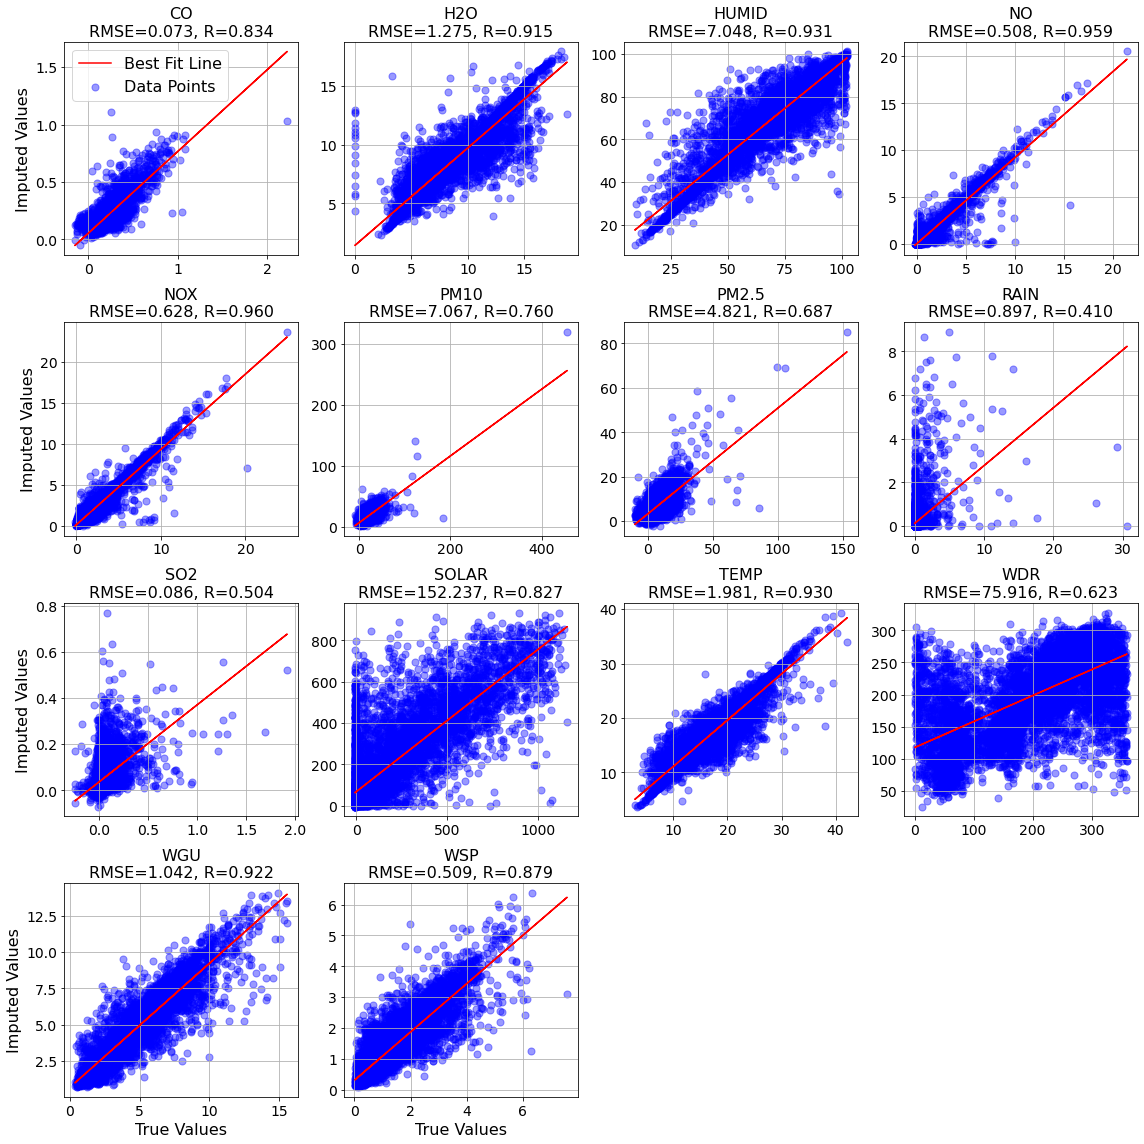

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import math

# Ensure save directories exist
save_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputation_plots"  # Folder to save plots
imputed_data_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs"  # Folder to save imputed CSVs
model_name = "MICEv2"  # Example model name
os.makedirs(save_path, exist_ok=True)
os.makedirs(imputed_data_path, exist_ok=True)

# Input directory for CSV files
input_directory = "/mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/input4imputation"

# Iterate over all CSV files in the input directory
for filename in os.listdir(input_directory):
    if filename.endswith('.csv'):
        # Extract the study site from the filename
        study_site = filename.split('_')[0]

        # Load the data for the current study site
        file_path = os.path.join(input_directory, filename)
        data = pd.read_csv(file_path)

        # Function to fix invalid time values (24:00 -> 00:00, adjust the date)
        def fix_time(row):
            if row['Time'] == '24:00':
                # Replace with 00:00 and increment the date
                new_time = '00:00'
                new_date = pd.to_datetime(row['Date'], format='%d/%m/%Y') + pd.Timedelta(days=1)
                return pd.Series({'Date': new_date.strftime('%d/%m/%Y'), 'Time': new_time})
            return pd.Series({'Date': row['Date'], 'Time': row['Time']})

        # Apply the fix to the dataset
        data[['Date', 'Time']] = data.apply(fix_time, axis=1)

        # Combine Date and Time into a datetime column
        data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M')
        data.set_index('datetime', inplace=True)
        data.drop(columns=['Date', 'Time'], inplace=True)

        # Analyze missingness
        print(f"Missing values summary for {study_site}:")
        print(data.isnull().sum())

        # Identify numerical columns
        numerical_cols = data.select_dtypes(include=[np.number]).columns

        # Backup of original dataset with missing data
        original_data_with_missing = data.copy()

        # Scale the data
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data[numerical_cols])

        # Create simulated missing data (20% missing values randomly per column)
        np.random.seed(42)
        simulated_missing = data.copy()
        for col in numerical_cols:
            mask = np.random.rand(len(simulated_missing)) < 0.2  # 20% missingness per column
            simulated_missing.loc[mask, col] = np.nan

        # Scale the simulated missing data
        simulated_missing_scaled = scaler.transform(simulated_missing[numerical_cols])

        # Impute data using MICE with ExtraTreesRegressor and posterior sampling disabled
        mice_imputer = IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
                                        max_iter=20,
                                        tol=1e-4,
                                        sample_posterior=False,  # Posterior sampling disabled
                                        random_state=42)

        imputed_data_scaled = mice_imputer.fit_transform(simulated_missing_scaled)
        imputed_data = scaler.inverse_transform(imputed_data_scaled)  # Convert back to original scale
        imputed_df = pd.DataFrame(imputed_data, columns=numerical_cols, index=simulated_missing.index)

        # Merge imputed data back into the original dataset
        imputed_data_final = original_data_with_missing.copy()
        imputed_data_final.update(imputed_df)  # Replace missing values with imputed data

        # Save the updated dataset to a CSV file
        output_csv_filename = f"{imputed_data_path}/{study_site}_imputed_data.csv"
        imputed_data_final.reset_index().to_csv(output_csv_filename, index=False)
        print(f"Imputed data saved for {study_site} to {output_csv_filename}")

        # Scatterplots with RMSE, R, and Best-Fit Line
        num_cols = 4  # Number of columns in the scatterplot grid
        num_rows = math.ceil(len(numerical_cols) / num_cols)  # Dynamically calculate rows
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))  # Adjust figure size
        axes = axes.flatten()  # Flatten the axes array for easier indexing

        for i, col in enumerate(numerical_cols):
            ax = axes[i]

            # Get true and imputed values for the current column
            true_values = data[col][simulated_missing[col].isna()]
            imputed_values = imputed_df.loc[true_values.index, col]

            # Ensure no NaNs in the comparison
            valid_mask = ~np.isnan(true_values) & ~np.isnan(imputed_values)
            true_values_clean = true_values[valid_mask]
            imputed_values_clean = imputed_values[valid_mask]

            if len(true_values_clean) > 0:
                # Calculate RMSE and R
                rmse = np.sqrt(mean_squared_error(true_values_clean, imputed_values_clean))
                r = np.corrcoef(true_values_clean, imputed_values_clean)[0, 1]

                # Scatterplot with larger marker size
                ax.scatter(true_values_clean, imputed_values_clean, s=50, alpha=0.4, color="blue", label='Data Points')  # Inline marker size

                # Add y-axis label only for the first column
                if i % num_cols == 0:
                    ax.set_ylabel('Imputed Values', fontsize=16)  # Inline font size

                # Add x-axis label only for the last row
                if i >= len(axes) - num_cols:
                    ax.set_xlabel('True Values', fontsize=16)  # Inline font size

                ax.set_title(f'{col}\nRMSE={rmse:.3f}, R={r:.3f}', fontsize=16)  # Inline font size
                ax.tick_params(axis='both', which='major', labelsize=14)  # Increased tick font size

                # Best-fit line
                x = np.array(true_values_clean).reshape(-1, 1)
                y = np.array(imputed_values_clean)
                model = LinearRegression().fit(x, y)
                best_fit_line = model.predict(x)
                ax.plot(true_values_clean, best_fit_line, color='red', label='Best Fit Line')  # Inline color

                if i == 0:  # Only add legend to the first subplot
                    ax.legend(fontsize=16)
                ax.grid(True)

        # Hide any unused subplots
        for j in range(len(numerical_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()  # Ensure no overlap between subplots
        scatterplot_filename = f"{save_path}/{study_site}_{model_name}_Scatterplots.png"
        plt.savefig(scatterplot_filename, dpi=300)
        plt.show()


In [34]:
import os
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import math

# Ensure save directories exist
save_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputation_plots"  # Folder to save plots
imputed_data_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs"  # Folder to save imputed CSVs
model_name = "MICE_XGB"  # Example model name
os.makedirs(save_path, exist_ok=True)
os.makedirs(imputed_data_path, exist_ok=True)

# Input directory for CSV files
input_directory = "/mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/input4imputation"

# Iterate over all CSV files in the input directory
for filename in os.listdir(input_directory):
    if filename.endswith('.csv'):
        # Extract the study site from the filename
        study_site = filename.split('_')[0]

        # Load the data for the current study site
        file_path = os.path.join(input_directory, filename)
        data = pd.read_csv(file_path)

        # Function to fix invalid time values (24:00 -> 00:00, adjust the date)
        def fix_time(row):
            if row['Time'] == '24:00':
                # Replace with 00:00 and increment the date
                new_time = '00:00'
                new_date = pd.to_datetime(row['Date'], format='%d/%m/%Y') + pd.Timedelta(days=1)
                return pd.Series({'Date': new_date.strftime('%d/%m/%Y'), 'Time': new_time})
            return pd.Series({'Date': row['Date'], 'Time': row['Time']})

        # Apply the fix to the dataset
        data[['Date', 'Time']] = data.apply(fix_time, axis=1)

        # Combine Date and Time into a datetime column
        data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M')
        data.set_index('datetime', inplace=True)
        data.drop(columns=['Date', 'Time'], inplace=True)

        # Analyze missingness
        print(f"Missing values summary for {study_site}:")
        print(data.isnull().sum())

        # Identify numerical columns
        numerical_cols = data.select_dtypes(include=[np.number]).columns

        # Backup of original dataset with missing data
        original_data_with_missing = data.copy()

        # Scale the data
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data[numerical_cols])

        # Create simulated missing data (20% missing values randomly per column)
        np.random.seed(42)
        simulated_missing = data.copy()
        for col in numerical_cols:
            mask = np.random.rand(len(simulated_missing)) < 0.2  # 20% missingness per column
            simulated_missing.loc[mask, col] = np.nan

        # Scale the simulated missing data
        simulated_missing_scaled = scaler.transform(simulated_missing[numerical_cols])

        # Impute data using MICE with XGBRegressor
        mice_imputer_xgb = IterativeImputer(estimator=XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
                                            max_iter=20,
                                            tol=1e-4,
                                            sample_posterior=False,  # Posterior sampling disabled for XGBRegressor
                                            random_state=42)

        imputed_data_scaled_xgb = mice_imputer_xgb.fit_transform(simulated_missing_scaled)
        imputed_data_xgb = scaler.inverse_transform(imputed_data_scaled_xgb)  # Convert back to original scale
        imputed_df_xgb = pd.DataFrame(imputed_data_xgb, columns=numerical_cols, index=simulated_missing.index)

        # Merge imputed data back into the original dataset
        imputed_data_final_xgb = original_data_with_missing.copy()
        imputed_data_final_xgb.update(imputed_df_xgb)  # Replace missing values with imputed data

        # Save the updated dataset to a CSV file
        output_csv_filename_xgb = f"{imputed_data_path}/{study_site}_imputed_data_xgb.csv"
        imputed_data_final_xgb.reset_index().to_csv(output_csv_filename_xgb, index=False)
        print(f"Imputed data saved for {study_site} to {output_csv_filename_xgb}")

        # Scatterplots with RMSE, R, and Best-Fit Line
        num_cols = 4  # Number of columns in the scatterplot grid
        num_rows = math.ceil(len(numerical_cols) / num_cols)  # Dynamically calculate rows
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))  # Adjust figure size
        axes = axes.flatten()  # Flatten the axes array for easier indexing

        for i, col in enumerate(numerical_cols):
            ax = axes[i]

            # Get true and imputed values for the current column
            true_values = data[col][simulated_missing[col].isna()]
            imputed_values = imputed_df_xgb.loc[true_values.index, col]

            # Ensure no NaNs in the comparison
            valid_mask = ~np.isnan(true_values) & ~np.isnan(imputed_values)
            true_values_clean = true_values[valid_mask]
            imputed_values_clean = imputed_values[valid_mask]

            if len(true_values_clean) > 0:
                # Calculate RMSE and R
                rmse = np.sqrt(mean_squared_error(true_values_clean, imputed_values_clean))
                r = np.corrcoef(true_values_clean, imputed_values_clean)[0, 1]

                # Scatterplot with larger marker size
                ax.scatter(true_values_clean, imputed_values_clean, s=50, alpha=0.4, color="blue", label='Data Points')  # Inline marker size

                # Add y-axis label only for the first column
                if i % num_cols == 0:
                    ax.set_ylabel('Imputed Values', fontsize=16)  # Inline font size

                # Add x-axis label only for the last row
                if i >= len(axes) - num_cols:
                    ax.set_xlabel('True Values', fontsize=16)  # Inline font size

                ax.set_title(f'{col}\nRMSE={rmse:.3f}, R={r:.3f}', fontsize=16)  # Inline font size
                ax.tick_params(axis='both', which='major', labelsize=14)  # Increased tick font size

                # Best-fit line
                x = np.array(true_values_clean).reshape(-1, 1)
                y = np.array(imputed_values_clean)
                model = LinearRegression().fit(x, y)
                best_fit_line = model.predict(x)
                ax.plot(true_values_clean, best_fit_line, color='red', label='Best Fit Line')  # Inline color

                if i == 0:  # Only add legend to the first subplot
                    ax.legend(fontsize=16)
                ax.grid(True)

        # Hide any unused subplots
        for j in range(len(numerical_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()  # Ensure no overlap between subplots
        scatterplot_filename = f"{save_path}/{study_site}_{model_name}_Scatterplots.png"
        plt.savefig(scatterplot_filename, dpi=300)
        plt.show()


Missing values summary for LIDCOMBE:
CO       3231
H2O      3211
HUMID     171
NO       2382
NOX      2382
PM10      422
PM2.5    1547
RAIN      633
SO2      2615
SOLAR     164
TEMP      171
WDR       288
WGU      9150
WSP       288
dtype: int64


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import math

# Ensure save directories exist
save_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputation_plots_knn"  # Folder to save plots
imputed_data_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs_knn"  # Folder to save imputed CSVs
model_name = "MICE_KNN"  # Example model name
os.makedirs(save_path, exist_ok=True)
os.makedirs(imputed_data_path, exist_ok=True)

# Input directory for CSV files
input_directory = "/mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/input4imputation"

# Iterate over all CSV files in the input directory
for filename in os.listdir(input_directory):
    if filename.endswith('.csv'):
        # Extract the study site from the filename
        study_site = filename.split('_')[0]

        # Load the data for the current study site
        file_path = os.path.join(input_directory, filename)
        data = pd.read_csv(file_path)

        # Function to fix invalid time values (24:00 -> 00:00, adjust the date)
        def fix_time(row):
            if row['Time'] == '24:00':
                # Replace with 00:00 and increment the date
                new_time = '00:00'
                new_date = pd.to_datetime(row['Date'], format='%d/%m/%Y') + pd.Timedelta(days=1)
                return pd.Series({'Date': new_date.strftime('%d/%m/%Y'), 'Time': new_time})
            return pd.Series({'Date': row['Date'], 'Time': row['Time']})

        # Apply the fix to the dataset
        data[['Date', 'Time']] = data.apply(fix_time, axis=1)

        # Combine Date and Time into a datetime column
        data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M')
        data.set_index('datetime', inplace=True)
        data.drop(columns=['Date', 'Time'], inplace=True)

        # Analyze missingness
        print(f"Missing values summary for {study_site}:")
        print(data.isnull().sum())

        # Identify numerical columns
        numerical_cols = data.select_dtypes(include=[np.number]).columns

        # Backup of original dataset with missing data
        original_data_with_missing = data.copy()

        # Scale the data
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data[numerical_cols])

        # Create simulated missing data (20% missing values randomly per column)
        np.random.seed(42)
        simulated_missing = data.copy()
        for col in numerical_cols:
            mask = np.random.rand(len(simulated_missing)) < 0.2  # 20% missingness per column
            simulated_missing.loc[mask, col] = np.nan

        # Scale the simulated missing data
        simulated_missing_scaled = scaler.transform(simulated_missing[numerical_cols])

        # Impute data using MICE with KNeighborsRegressor
        mice_imputer_knn = IterativeImputer(estimator=KNeighborsRegressor(n_neighbors=5, weights='distance'),
                                            max_iter=20,
                                            tol=1e-4,
                                            random_state=42)

        imputed_data_scaled_knn = mice_imputer_knn.fit_transform(simulated_missing_scaled)
        imputed_data_knn = scaler.inverse_transform(imputed_data_scaled_knn)  # Convert back to original scale
        imputed_df_knn = pd.DataFrame(imputed_data_knn, columns=numerical_cols, index=simulated_missing.index)

        # Merge imputed data back into the original dataset
        imputed_data_final_knn = original_data_with_missing.copy()
        imputed_data_final_knn.update(imputed_df_knn)  # Replace missing values with imputed data

        # Save the updated dataset to a CSV file
        output_csv_filename_knn = f"{imputed_data_path}/{study_site}_imputed_data_knn.csv"
        imputed_data_final_knn.reset_index().to_csv(output_csv_filename_knn, index=False)
        print(f"Imputed data saved for {study_site} to {output_csv_filename_knn}")

        # Scatterplots with RMSE, R, and Best-Fit Line
        num_cols = 4  # Number of columns in the scatterplot grid
        num_rows = math.ceil(len(numerical_cols) / num_cols)  # Dynamically calculate rows
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))  # Adjust figure size
        axes = axes.flatten()  # Flatten the axes array for easier indexing

        for i, col in enumerate(numerical_cols):
            ax = axes[i]

            # Get true and imputed values for the current column
            true_values = data[col][simulated_missing[col].isna()]
            imputed_values = imputed_df_knn.loc[true_values.index, col]

            # Ensure no NaNs in the comparison
            valid_mask = ~np.isnan(true_values) & ~np.isnan(imputed_values)
            true_values_clean = true_values[valid_mask]
            imputed_values_clean = imputed_values[valid_mask]

            if len(true_values_clean) > 0:
                # Calculate RMSE and R
                rmse = np.sqrt(mean_squared_error(true_values_clean, imputed_values_clean))
                r = np.corrcoef(true_values_clean, imputed_values_clean)[0, 1]

                # Scatterplot with larger marker size
                ax.scatter(true_values_clean, imputed_values_clean, s=50, alpha=0.4, color="blue", label='Data Points')  # Inline marker size

                # Add y-axis label only for the first column
                if i % num_cols == 0:
                    ax.set_ylabel('Imputed Values', fontsize=16)  # Inline font size

                # Add x-axis label only for the last row
                if i >= len(axes) - num_cols:
                    ax.set_xlabel('True Values', fontsize=16)  # Inline font size

                ax.set_title(f'{col}\nRMSE={rmse:.3f}, R={r:.3f}', fontsize=16)  # Inline font size
                ax.tick_params(axis='both', which='major', labelsize=14)  # Increased tick font size

                # Best-fit line
                x = np.array(true_values_clean).reshape(-1, 1)
                y = np.array(imputed_values_clean)
                model = LinearRegression().fit(x, y)
                best_fit_line = model.predict(x)
                ax.plot(true_values_clean, best_fit_line, color='red', label='Best Fit Line')  # Inline color

                if i == 0:  # Only add legend to the first subplot
                    ax.legend(fontsize=16)
                ax.grid(True)

        # Hide any unused subplots
        for j in range(len(numerical_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()  # Ensure no overlap between subplots
        scatterplot_filename = f"{save_path}/{study_site}_{model_name}_Scatterplots.png"
        plt.savefig(scatterplot_filename, dpi=300)
        plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import math

# Ensure save directories exist
save_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputation_plots_knn"  # Folder to save plots
imputed_data_path = "./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs_knn"  # Folder to save imputed CSVs
model_name = "KNN_Imputer"  # Example model name
os.makedirs(save_path, exist_ok=True)
os.makedirs(imputed_data_path, exist_ok=True)

# Input directory for CSV files
input_directory = "/mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/input4imputation"

# Iterate over all CSV files in the input directory
for filename in os.listdir(input_directory):
    if filename.endswith('.csv'):
        # Extract the study site from the filename
        study_site = filename.split('_')[0]

        # Load the data for the current study site
        file_path = os.path.join(input_directory, filename)
        data = pd.read_csv(file_path)

        # Function to fix invalid time values (24:00 -> 00:00, adjust the date)
        def fix_time(row):
            if row['Time'] == '24:00':
                # Replace with 00:00 and increment the date
                new_time = '00:00'
                new_date = pd.to_datetime(row['Date'], format='%d/%m/%Y') + pd.Timedelta(days=1)
                return pd.Series({'Date': new_date.strftime('%d/%m/%Y'), 'Time': new_time})
            return pd.Series({'Date': row['Date'], 'Time': row['Time']})

        # Apply the fix to the dataset
        data[['Date', 'Time']] = data.apply(fix_time, axis=1)

        # Combine Date and Time into a datetime column
        data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M')
        data.set_index('datetime', inplace=True)
        data.drop(columns=['Date', 'Time'], inplace=True)

        # Analyze missingness
        print(f"Missing values summary for {study_site}:")
        print(data.isnull().sum())

        # Identify numerical columns
        numerical_cols = data.select_dtypes(include=[np.number]).columns

        # Backup of original dataset with missing data
        original_data_with_missing = data.copy()

        # Scale the data
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data[numerical_cols])

        # Create simulated missing data (20% missing values randomly per column)
        np.random.seed(42)
        simulated_missing = data.copy()
        for col in numerical_cols:
            mask = np.random.rand(len(simulated_missing)) < 0.2  # 20% missingness per column
            simulated_missing.loc[mask, col] = np.nan

        # Scale the simulated missing data
        simulated_missing_scaled = scaler.transform(simulated_missing[numerical_cols])

        # Impute data using KNNImputer
        knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
        imputed_data_scaled_knn = knn_imputer.fit_transform(simulated_missing_scaled)
        imputed_data_knn = scaler.inverse_transform(imputed_data_scaled_knn)  # Convert back to original scale
        imputed_df_knn = pd.DataFrame(imputed_data_knn, columns=numerical_cols, index=simulated_missing.index)

        # Merge imputed data back into the original dataset
        imputed_data_final_knn = original_data_with_missing.copy()
        imputed_data_final_knn.update(imputed_df_knn)  # Replace missing values with imputed data

        # Save the updated dataset to a CSV file
        output_csv_filename_knn = f"{imputed_data_path}/{study_site}_imputed_data_knn.csv"
        imputed_data_final_knn.reset_index().to_csv(output_csv_filename_knn, index=False)
        print(f"Imputed data saved for {study_site} to {output_csv_filename_knn}")

        # Scatterplots with RMSE, R, and Best-Fit Line
        num_cols = 4  # Number of columns in the scatterplot grid
        num_rows = math.ceil(len(numerical_cols) / num_cols)  # Dynamically calculate rows
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))  # Adjust figure size
        axes = axes.flatten()  # Flatten the axes array for easier indexing

        for i, col in enumerate(numerical_cols):
            ax = axes[i]

            # Get true and imputed values for the current column
            true_values = data[col][simulated_missing[col].isna()]
            imputed_values = imputed_df_knn.loc[true_values.index, col]

            # Ensure no NaNs in the comparison
            valid_mask = ~np.isnan(true_values) & ~np.isnan(imputed_values)
            true_values_clean = true_values[valid_mask]
            imputed_values_clean = imputed_values[valid_mask]

            if len(true_values_clean) > 0:
                # Calculate RMSE and R
                rmse = np.sqrt(mean_squared_error(true_values_clean, imputed_values_clean))
                r = np.corrcoef(true_values_clean, imputed_values_clean)[0, 1]

                # Scatterplot with larger marker size
                ax.scatter(true_values_clean, imputed_values_clean, s=50, alpha=0.4, color="blue", label='Data Points')  # Inline marker size

                # Add y-axis label only for the first column
                if i % num_cols == 0:
                    ax.set_ylabel('Imputed Values', fontsize=16)  # Inline font size

                # Add x-axis label only for the last row
                if i >= len(axes) - num_cols:
                    ax.set_xlabel('True Values', fontsize=16)  # Inline font size

                ax.set_title(f'{col}\nRMSE={rmse:.3f}, R={r:.3f}', fontsize=16)  # Inline font size
                ax.tick_params(axis='both', which='major', labelsize=14)  # Increased tick font size

                # Best-fit line
                x = np.array(true_values_clean).reshape(-1, 1)
                y = np.array(imputed_values_clean)
                model = LinearRegression().fit(x, y)
                best_fit_line = model.predict(x)
                ax.plot(true_values_clean, best_fit_line, color='red', label='Best Fit Line')  # Inline color

                if i == 0:  # Only add legend to the first subplot
                    ax.legend(fontsize=16)
                ax.grid(True)

        # Hide any unused subplots
        for j in range(len(numerical_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()  # Ensure no overlap between subplots
        scatterplot_filename = f"{save_path}/{study_site}_{model_name}_Scatterplots.png"
        plt.savefig(scatterplot_filename, dpi=300)
        plt.show()


Bidirectional Recurrent Imputation for Time Series

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Masking
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define model name
model_name = "BRITS"

# Ensure save directories exist
save_path_brits = f"./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputation_plots_{model_name.lower()}"
imputed_data_path_brits = f"./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs_{model_name.lower()}"
os.makedirs(save_path_brits, exist_ok=True)
os.makedirs(imputed_data_path_brits, exist_ok=True)

# Input directory for CSV files
input_directory = "/mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/input4imputation"

# Function to create BRITS model
def create_brits(input_dim, time_steps):
    input_layer = Input(shape=(time_steps, input_dim))
    masked = Masking(mask_value=0.0)(input_layer)
    encoded = Bidirectional(LSTM(64, return_sequences=True))(masked)
    encoded = Bidirectional(LSTM(32, return_sequences=True))(encoded)
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(32, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='linear')(decoded)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mse')
    return model

# Parameters for BRITS
timesteps = 10  # Time steps for sequence-based modeling

# Iterate through all files
for filename in os.listdir(input_directory):
    if filename.endswith('.csv'):
        # Extract study site from the filename
        study_site = filename.split('_')[0]
        file_path = os.path.join(input_directory, filename)
        data = pd.read_csv(file_path)

        # Process datetime and fix invalid times
        def fix_time(row):
            if row['Time'] == '24:00':
                new_time = '00:00'
                new_date = pd.to_datetime(row['Date'], format='%d/%m/%Y') + pd.Timedelta(days=1)
                return pd.Series({'Date': new_date.strftime('%d/%m/%Y'), 'Time': new_time})
            return pd.Series({'Date': row['Date'], 'Time': row['Time']})

        data[['Date', 'Time']] = data.apply(fix_time, axis=1)
        data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M')
        data.set_index('datetime', inplace=True)
        data.drop(columns=['Date', 'Time'], inplace=True)

        # Analyze missingness
        print(f"Missing values summary for {study_site}:")
        print(data.isnull().sum())

        numerical_cols = data.select_dtypes(include=[np.number]).columns

        # Backup the original dataset
        original_data_with_missing = data.copy()

        # Scale data for imputers
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data[numerical_cols])

        # Simulated missing data (20% per column)
        np.random.seed(42)
        simulated_missing = data.copy()
        for col in numerical_cols:
            mask = np.random.rand(len(simulated_missing)) < 0.2
            simulated_missing.loc[mask, col] = np.nan
        simulated_missing_scaled = scaler.transform(simulated_missing[numerical_cols])

        # Prepare sequences for BRITS
        sequences = []
        for i in range(len(data_scaled) - timesteps):
            sequences.append(data_scaled[i:i + timesteps])
        X_brits = np.array(sequences)

        # Train BRITS model
        input_dim = len(numerical_cols)
        brits_model = create_brits(input_dim=input_dim, time_steps=timesteps)
        early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        brits_model.fit(X_brits, X_brits, epochs=20, batch_size=32, callbacks=[early_stopping])

        # Predict missing values
        brits_predicted = brits_model.predict(X_brits)
        imputed_data_brits = scaler.inverse_transform(brits_predicted.reshape(-1, input_dim))
        imputed_df_brits = pd.DataFrame(imputed_data_brits[:len(simulated_missing)], columns=numerical_cols, index=simulated_missing.index)

        # Save BRITS-imputed dataset
        imputed_data_final_brits = original_data_with_missing.copy()
        imputed_data_final_brits.update(imputed_df_brits)
        output_csv_filename_brits = f"{imputed_data_path_brits}/{study_site}_{model_name.lower()}_imputed.csv"
        imputed_data_final_brits.reset_index().to_csv(output_csv_filename_brits, index=False)
        print(f"BRITS Imputation saved to {output_csv_filename_brits}")

        # ---------- Plots ----------
        # Scatterplot with RMSE and R
        for col in numerical_cols:
            plt.figure(figsize=(8, 6))
            true_values = data[col][simulated_missing[col].isna()]
            imputed_values = imputed_df_brits.loc[true_values.index, col]

            valid_mask = ~np.isnan(true_values) & ~np.isnan(imputed_values)
            true_values_clean = true_values[valid_mask]
            imputed_values_clean = imputed_values[valid_mask]

            if len(true_values_clean) > 0:
                rmse = np.sqrt(mean_squared_error(true_values_clean, imputed_values_clean))
                plt.scatter(true_values_clean, imputed_values_clean, alpha=0.5, color="blue", label=f'RMSE={rmse:.3f}')
                plt.plot([min(true_values_clean), max(true_values_clean)],
                         [min(true_values_clean), max(true_values_clean)], color='red', label='Best Fit Line')
                plt.title(f'Scatterplot: {col} ({model_name})', fontsize=14)
                plt.xlabel('True Values', fontsize=12)
                plt.ylabel('Imputed Values', fontsize=12)
                plt.legend(fontsize=10)
                plt.grid(True)
                scatterplot_filename = f"{save_path_brits}/{study_site}_scatter_{col}_{model_name.lower()}.png"
                plt.savefig(scatterplot_filename)
                plt.show()

        # Histogram Plot
        for col in numerical_cols:
            plt.figure(figsize=(8, 4))
            plt.hist(data[col].dropna(), bins=20, alpha=0.5, label='Original', color='blue')
            plt.hist(imputed_df_brits[col], bins=20, alpha=0.5, label='Imputed', color='orange')
            plt.title(f'Histogram: {col} ({model_name})', fontsize=12)
            plt.legend(fontsize=10)
            plt.grid(True)
            histogram_filename = f"{save_path_brits}/{study_site}_histogram_{col}_{model_name.lower()}.png"
            plt.savefig(histogram_filename)
            plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GRU
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Ensure save directories exist
model_name = "GRU-D"  # Model name
save_path_grud = f"./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputation_plots_{model_name.lower()}"
imputed_data_path_grud = f"./mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/imputed_csvs_{model_name.lower()}"
os.makedirs(save_path_grud, exist_ok=True)
os.makedirs(imputed_data_path_grud, exist_ok=True)

# Input directory for CSV files
input_directory = "/mnt/scratch_lustre/barthelx/Masrur/Nowcasting/Input_Data/input4imputation"

# Function to create GRU-D model
def create_gru_d_model(input_shape):
    inputs = Input(shape=(input_shape[1], input_shape[2]))  # Time series shape: (timesteps, features)
    x = GRU(64, return_sequences=False)(inputs)  # GRU for sequence data
    outputs = Dense(input_shape[2], activation='linear')(x)  # Output layer for imputation
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Function to create sequences for time-series data
def create_sequences(data, timesteps):
    sequences = []
    for i in range(len(data) - timesteps):
        sequences.append(data[i:i + timesteps])
    return np.array(sequences)

# Parameters for sequence creation
timesteps = 10  # Number of timesteps to look back

# Iterate through all files
for filename in os.listdir(input_directory):
    if filename.endswith('.csv'):
        # Extract study site from the filename
        study_site = filename.split('_')[0]
        file_path = os.path.join(input_directory, filename)
        data = pd.read_csv(file_path)

        # Process datetime and fix invalid times
        def fix_time(row):
            if row['Time'] == '24:00':
                new_time = '00:00'
                new_date = pd.to_datetime(row['Date'], format='%d/%m/%Y') + pd.Timedelta(days=1)
                return pd.Series({'Date': new_date.strftime('%d/%m/%Y'), 'Time': new_time})
            return pd.Series({'Date': row['Date'], 'Time': row['Time']})

        data[['Date', 'Time']] = data.apply(fix_time, axis=1)
        data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M')
        data.set_index('datetime', inplace=True)
        data.drop(columns=['Date', 'Time'], inplace=True)

        # Analyze missingness
        print(f"Missing values summary for {study_site}:")
        print(data.isnull().sum())

        numerical_cols = data.select_dtypes(include=[np.number]).columns

        # Backup the original dataset
        original_data_with_missing = data.copy()

        # Scale data
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data[numerical_cols])

        # Simulate missing data (20% per column)
        np.random.seed(42)
        simulated_missing = data.copy()
        for col in numerical_cols:
            mask = np.random.rand(len(simulated_missing)) < 0.2
            simulated_missing.loc[mask, col] = np.nan

        simulated_missing_scaled = scaler.transform(simulated_missing[numerical_cols])

        # Create sequences
        X_sequences = create_sequences(simulated_missing_scaled, timesteps)
        y_sequences = simulated_missing_scaled[timesteps:]

        # Replace NaNs in target values with 0 for training
        y_sequences = np.nan_to_num(y_sequences)

        # Train GRU-D model
        input_shape = X_sequences.shape
        grud_model = create_gru_d_model(input_shape)
        early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        grud_model.fit(X_sequences, y_sequences, epochs=20, batch_size=32, verbose=1, callbacks=[early_stopping])

        # Impute missing values
        predicted_values = grud_model.predict(X_sequences)
        imputed_data_grud = scaler.inverse_transform(predicted_values)
        imputed_df_grud = pd.DataFrame(imputed_data_grud[:len(simulated_missing)], columns=numerical_cols, index=simulated_missing.index[timesteps:])

        # Save the imputed dataset
        imputed_data_final_grud = original_data_with_missing.copy()
        imputed_data_final_grud.update(imputed_df_grud)
        output_csv_filename_grud = f"{imputed_data_path_grud}/{study_site}_{model_name.lower()}_imputed.csv"
        imputed_data_final_grud.reset_index().to_csv(output_csv_filename_grud, index=False)
        print(f"GRU-D Imputation saved to {output_csv_filename_grud}")

        # ---------- Plotting ----------
        # Histogram
        for col in numerical_cols:
            plt.figure(figsize=(8, 4))
            plt.hist(data[col].dropna(), bins=20, alpha=0.5, label='Original', color='blue')
            plt.hist(imputed_df_grud[col], bins=20, alpha=0.5, label='Imputed', color='orange')
            plt.title(f'Histogram: {col} ({model_name})', fontsize=14)
            plt.legend(fontsize=10)
            plt.grid(True)
            plt.savefig(f"{save_path_grud}/{study_site}_histogram_{col}_{model_name.lower()}.png")
            plt.show()

        # Scatterplot
        for col in numerical_cols:
            plt.figure(figsize=(8, 6))
            true_values = data[col][simulated_missing[col].isna()]
            imputed_values = imputed_df_grud.loc[true_values.index, col]

            valid_mask = ~np.isnan(true_values) & ~np.isnan(imputed_values)
            true_values_clean = true_values[valid_mask]
            imputed_values_clean = imputed_values[valid_mask]

            if len(true_values_clean) > 0:
                rmse = np.sqrt(mean_squared_error(true_values_clean, imputed_values_clean))
                plt.scatter(true_values_clean, imputed_values_clean, alpha=0.5, color="blue", label=f'RMSE={rmse:.3f}')
                plt.plot([min(true_values_clean), max(true_values_clean)],
                         [min(true_values_clean), max(true_values_clean)], color='red', label='Best Fit Line')
                plt.title(f'Scatterplot: {col} ({model_name})', fontsize=14)
                plt.xlabel('True Values', fontsize=12)
                plt.ylabel('Imputed Values', fontsize=12)
                plt.legend(fontsize=10)
                plt.grid(True)
                plt.savefig(f"{save_path_grud}/{study_site}_scatter_{col}_{model_name.lower()}.png")
                plt.show()
